In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns

import pandas as pd
import numpy as np

from utilitarios.visualizacao import EstatisticasDescritivas
sns.set(style="whitegrid", context="notebook", font_scale=1.2)


In [2]:
df_unificado_filtrado = pd.read_parquet(r'dados_brutos/base_de_dados_filtrada.parquet')
base_taxas_de_violencia_2010_2022= pd.read_parquet(r'dados_brutos/taxas_de_violencia_2008_2022.parquet')
base_taxas_de_violencia_2010_2022_filtrada = pd.read_parquet(r'dados_brutos/taxas_de_violencia_2008_2022_filtrada.parquet')

In [3]:
df_unificado_filtrado.columns = [col.lower() for col in df_unificado_filtrado.columns]
base_taxas_de_violencia_2010_2022.columns = [col.lower() for col in base_taxas_de_violencia_2010_2022.columns]
base_taxas_de_violencia_2010_2022_filtrada.columns = [col.lower() for col in base_taxas_de_violencia_2010_2022_filtrada.columns]

In [4]:
ed_bd_filtr = EstatisticasDescritivas(df_unificado_filtrado)


In [5]:
base_taxas_de_violencia_2010_2022_filtrada.iloc[:,5:].describe().round(3)

,taxa_2008,taxa_2009,taxa_2010,taxa_2011,taxa_2012,taxa_2013,taxa_2014,taxa_2015,taxa_2016,taxa_2017,taxa_2018,taxa_2019,taxa_2020,taxa_2021,taxa_2022
count,282.000,282.000,282.000,282.000,282.000,282.000,282.000,282.000,282.000,282.000,282.000,282.000,282.000,282.000,282.000
mean,31.457,31.539,31.608,31.499,33.587,32.831,33.683,32.044,33.231,33.825,29.985,22.830,18.049,23.039,86.258
std,21.661,22.303,22.592,21.917,22.814,21.296,22.180,21.030,23.225,25.016,22.676,15.834,20.890,17.181,486.628
min,0.860,0.760,0.000,2.500,0.690,1.370,3.190,0.670,2.440,2.070,0.000,0.770,0.000,1.080,0.960
25%,14.010,14.665,14.620,14.100,16.093,15.492,16.132,14.397,13.605,12.975,11.550,9.800,0.305,9.195,9.518
50%,27.645,26.500,25.305,26.635,27.690,28.475,29.085,28.140,27.960,27.655,23.935,19.010,9.695,18.515,20.365
75%,43.132,41.498,42.820,42.408,44.958,45.973,47.375,45.838,47.450,48.565,42.470,32.988,32.085,34.122,36.915
max,108.850,123.680,113.670,105.400,120.270,106.830,121.280,95.730,118.260,137.200,110.940,71.630,97.790,78.410,7179.160


In [6]:
base_taxas_de_violencia_2010_2022_filtrada.iloc[:, 7:-1].melt(var_name='Ano', value_name='Taxa')


,Ano,Taxa
0,taxa_2010,3.35
1,taxa_2010,46.30
2,taxa_2010,28.24
3,taxa_2010,46.09
4,taxa_2010,9.61
...,...,...
3379,taxa_2021,42.39
3380,taxa_2021,10.91
3381,taxa_2021,37.87
3382,taxa_2021,23.90


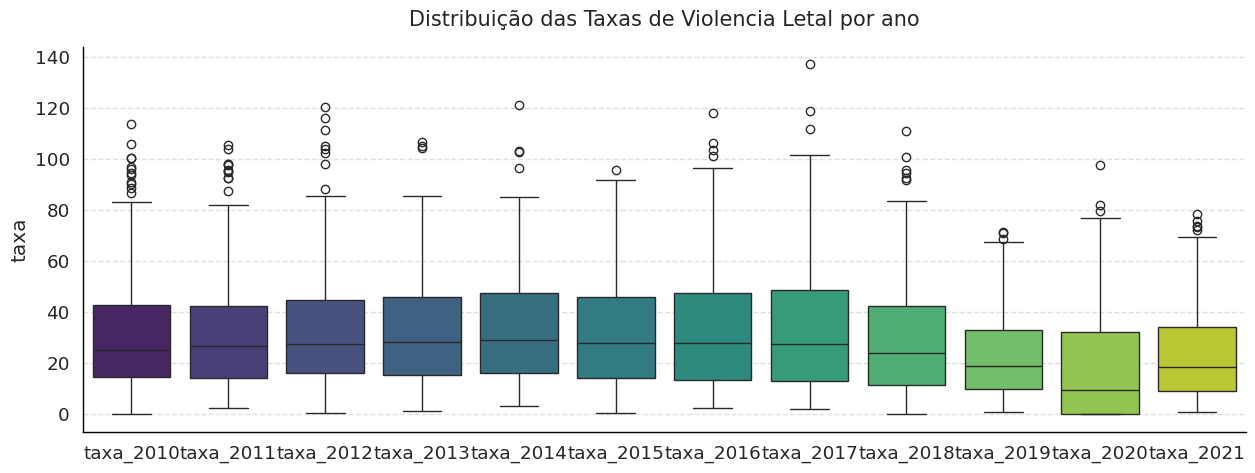

In [19]:
df_plot = base_taxas_de_violencia_2010_2022_filtrada.iloc[:, 7:-1].melt(var_name='Ano', value_name='Taxa')
df_plot_ed_ano = EstatisticasDescritivas(df_plot)
df_plot_ed_ano.plot_box_uf(
    titulo='Distribuição das Taxas de Violencia Letal por ano',
    y_label='taxa',
    x='Ano', 
    y='Taxa',
    hue='Ano'
    ) 


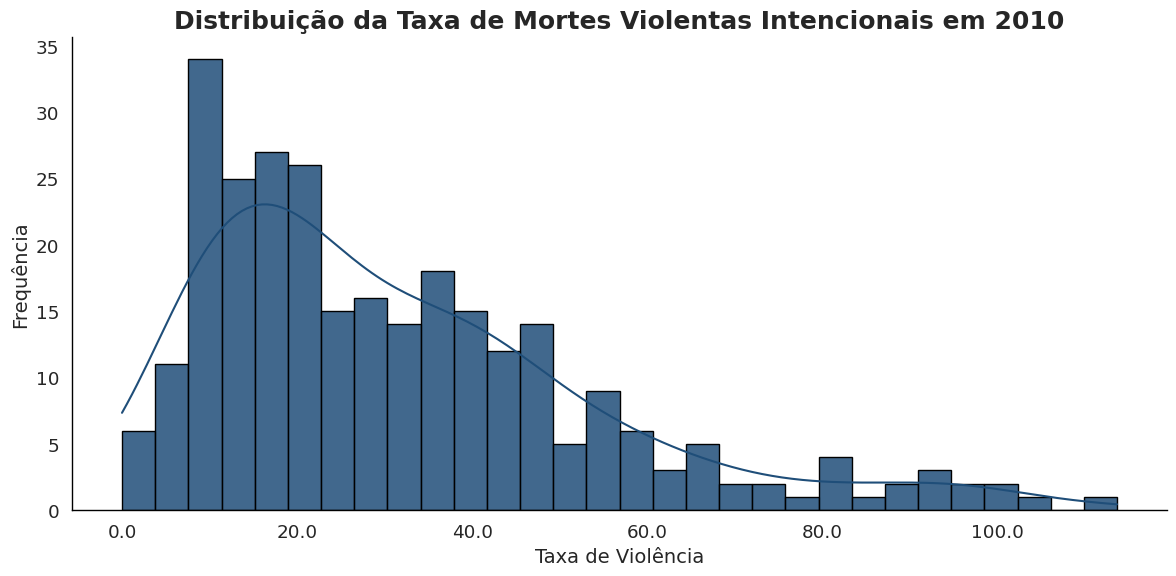

In [7]:
# Tamanho da figura
plt.figure(figsize=(12, 6))

# Cor azul escuro
azul_escuro = "#1f4e79"

# Histograma com azul escuro
ax = sns.histplot(
    data=df_unificado_filtrado,
    x='taxa_violencia',
    bins=30,
    kde=True,
    color=azul_escuro,
    edgecolor='black',
    alpha=0.85
)

# Título e rótulos
plt.title("Distribuição da Taxa de Mortes Violentas Intencionais em 2010", fontsize=18, weight='bold')
plt.xlabel("Taxa de Violência", fontsize=14)
plt.ylabel("Frequência", fontsize=14)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{int(y):,}'))

# Personalizando spines (bordas)
ax = plt.gca()  # pega o eixo atual
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1)    # controla grossura
ax.spines['bottom'].set_linewidth(1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)

# Layout final
plt.tight_layout()
plt.show()


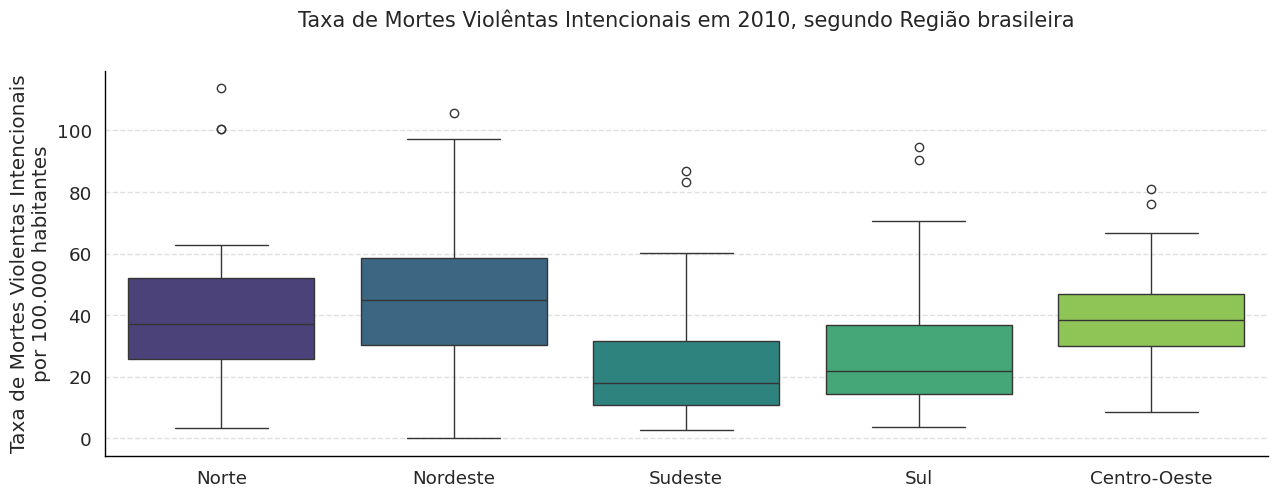

In [26]:
ed_bd_filtr.plot_box_uf('Taxa de Mortes Violêntas Intencionais em 2010, segundo Região brasileira\n', 
            'Taxa de Mortes Violentas Intencionais\npor 100.000 habitantes', 
            x='regiao',
            y='taxa_violencia',
            hue='regiao'
            )

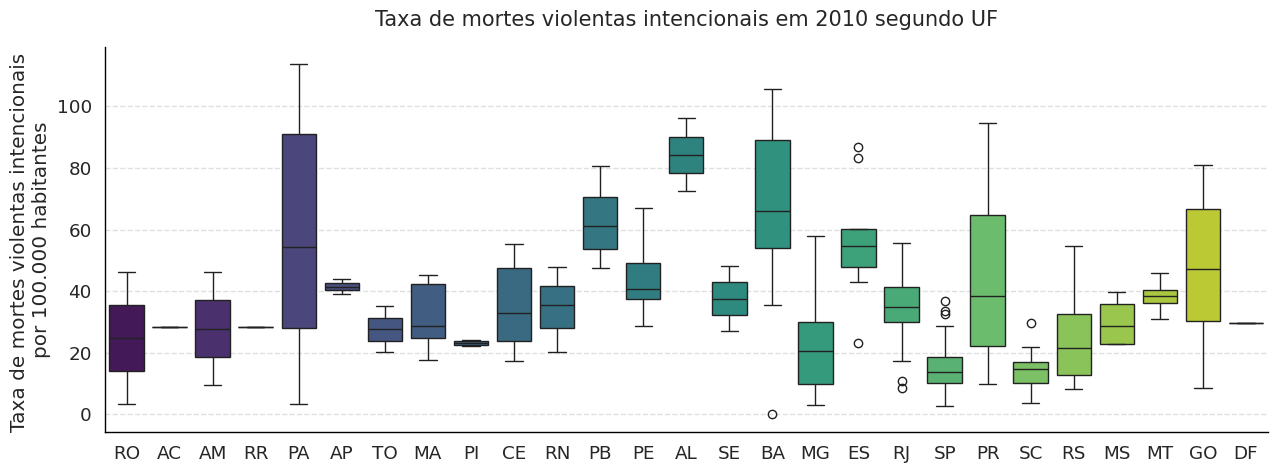

count    282.000
mean      31.608
std       22.592
min        0.000
25%       14.620
50%       25.305
75%       42.820
max      113.670
Name: taxa_violencia, dtype: float64

In [38]:
ed_bd_filtr.plot_box_uf(
    titulo='Taxa de mortes violentas intencionais em 2010 segundo UF',
    y_label='Taxa de mortes violentas intencionais \npor 100.000 habitantes',
    x='uf',
    y='taxa_violencia'
)

plt.show()
df_unificado_filtrado['taxa_violencia'].describe().round(3)


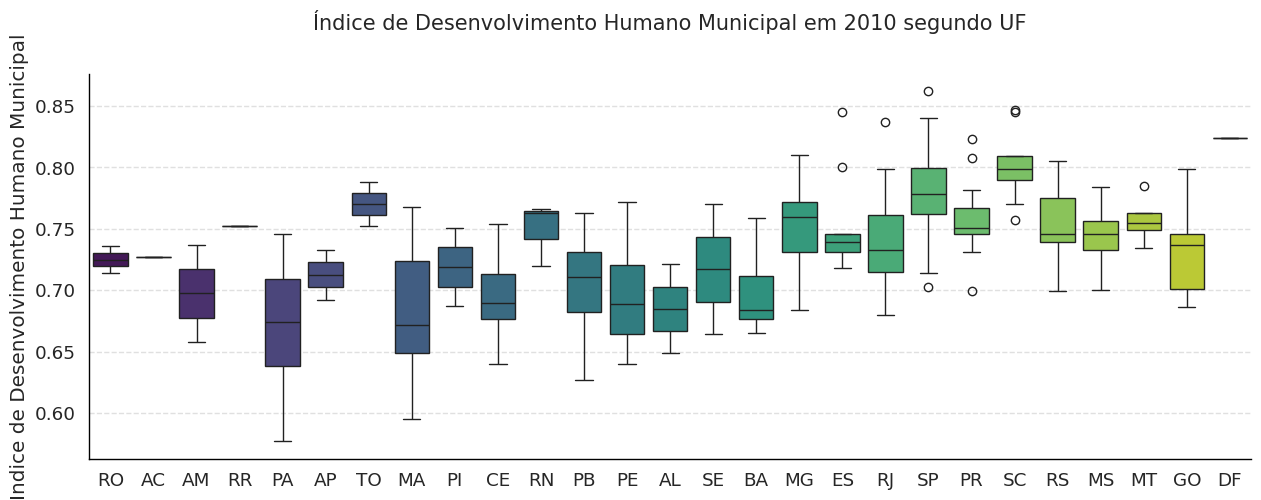

In [37]:
ed_bd_filtr.plot_box_uf(
    titulo='Índice de Desenvolvimento Humano Municipal em 2010 segundo UF\n',
    y_label='Indice de Desenvolvimento Humano Municipal',
    x='uf',
    y='idhm_2010'
)
plt.show()

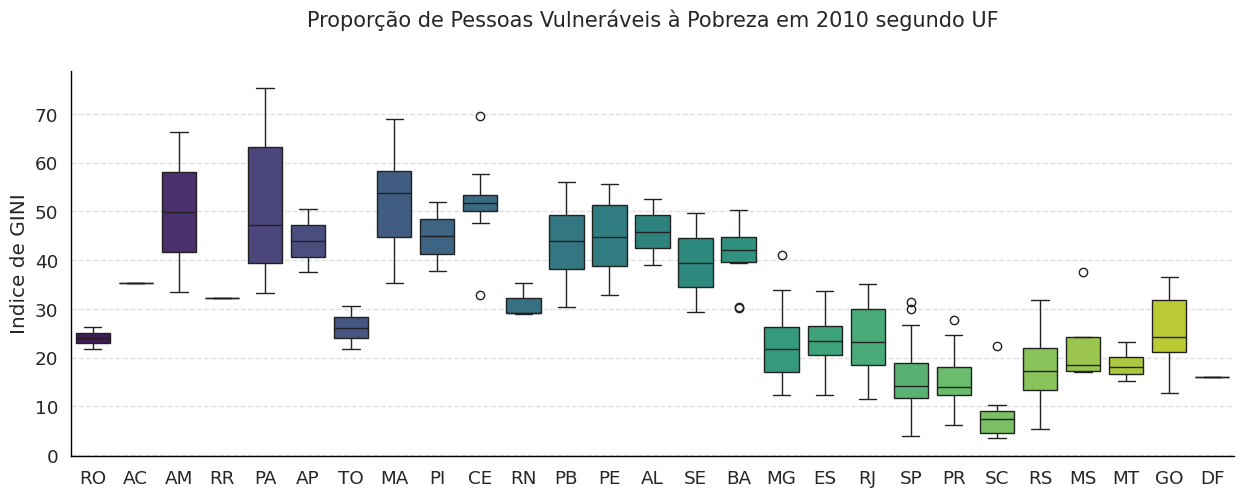

In [43]:
ed_bd_filtr.plot_box_uf(
    titulo='Proporção de Pessoas Vulneráveis à Pobreza em 2010 segundo UF\n',
    y_label='Indice de GINI',
    x='uf',
    y='prop_vulneraveis_pobreza'
)
plt.show()

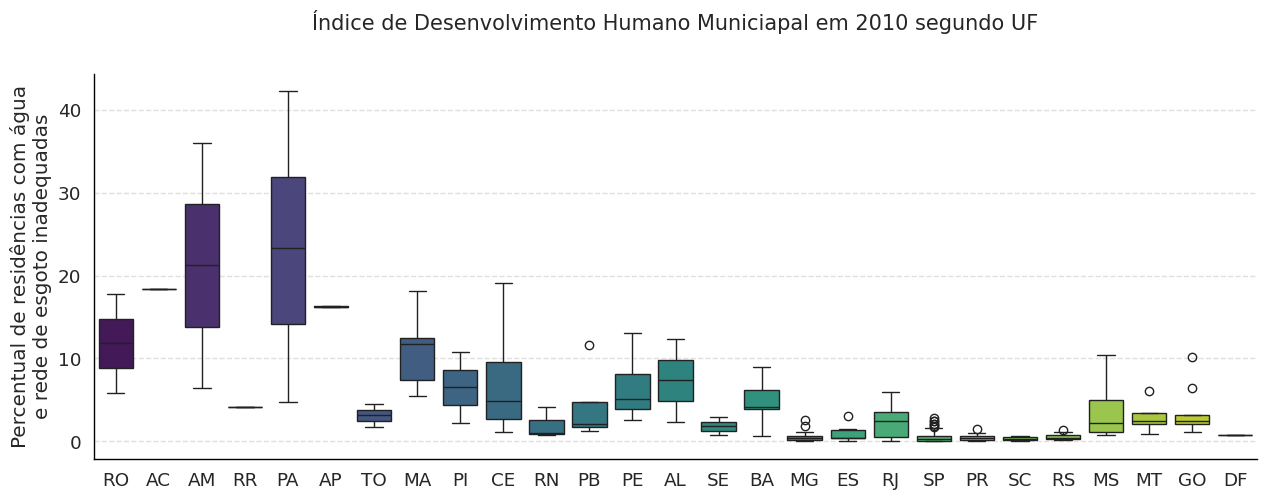

In [21]:
ed_bd_filtr.plot_box_uf(
    titulo='Índice de Desenvolvimento Humano Municiapal em 2010 segundo UF\n',
    y_label='Percentual de residências com água\ne rede de esgoto inadequadas',
    x='uf',
    y='agua-esgotamento_inadequados'
)

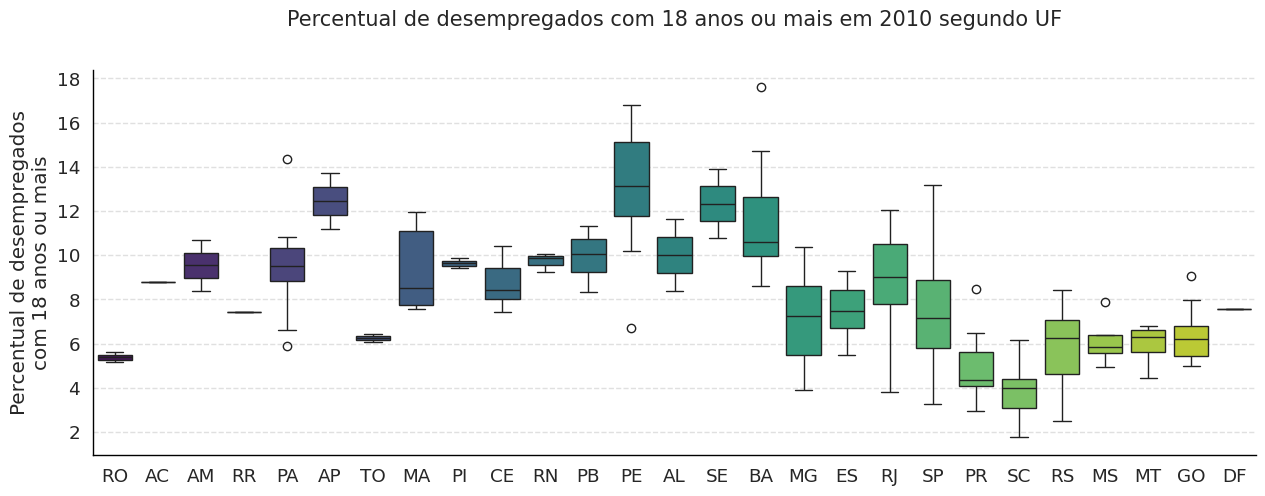

In [31]:
ed_bd_filtr.plot_box_uf(
    titulo='Percentual de desempregados com 18 anos ou mais em 2010 segundo UF\n',
    y_label='Percentual de desempregados\ncom 18 anos ou mais',
    x='uf',
    y='taxa_desocup_18_mais'
)
plt.show()

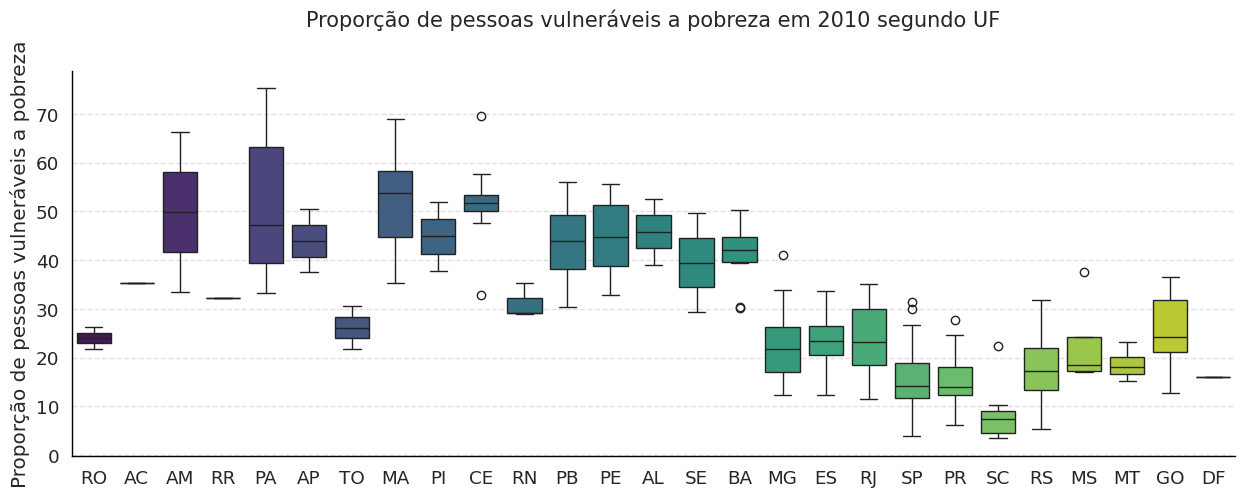

In [32]:
ed_bd_filtr.plot_box_uf(
    titulo='Proporção de pessoas vulneráveis a pobreza em 2010 segundo UF\n',
    y_label='Proporção de pessoas vulneráveis a pobreza',
    x='uf',
    y='prop_vulneraveis_pobreza'
)
plt.show()

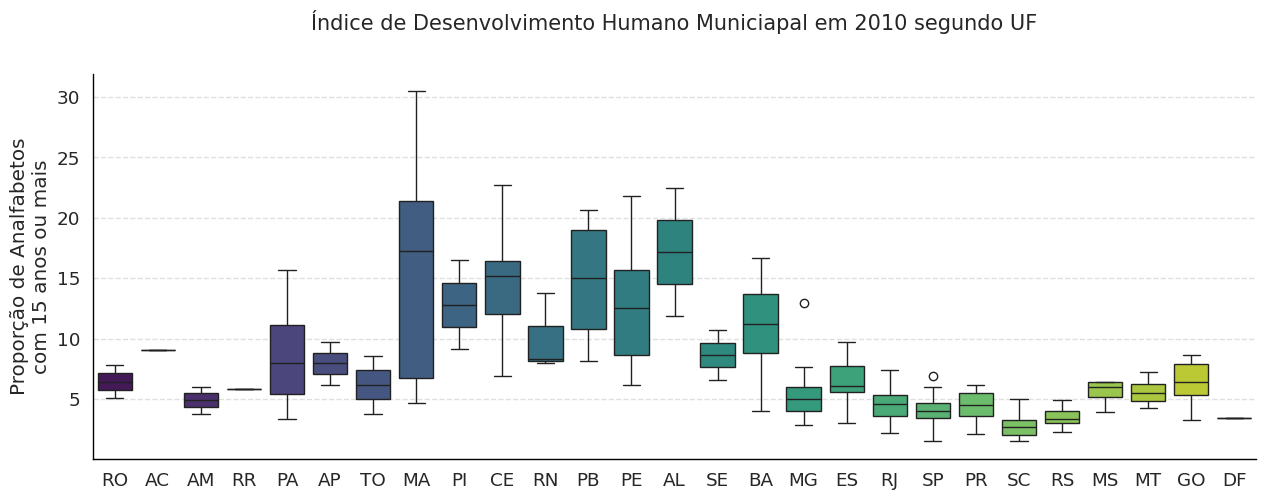

In [34]:
ed_bd_filtr.plot_box_uf(
    titulo='Índice de Desenvolvimento Humano Municiapal em 2010 segundo UF\n',
    y_label='Proporção de Analfabetos\ncom 15 anos ou mais',
    x='uf',
    y='analfabetismo_15_anos'
)

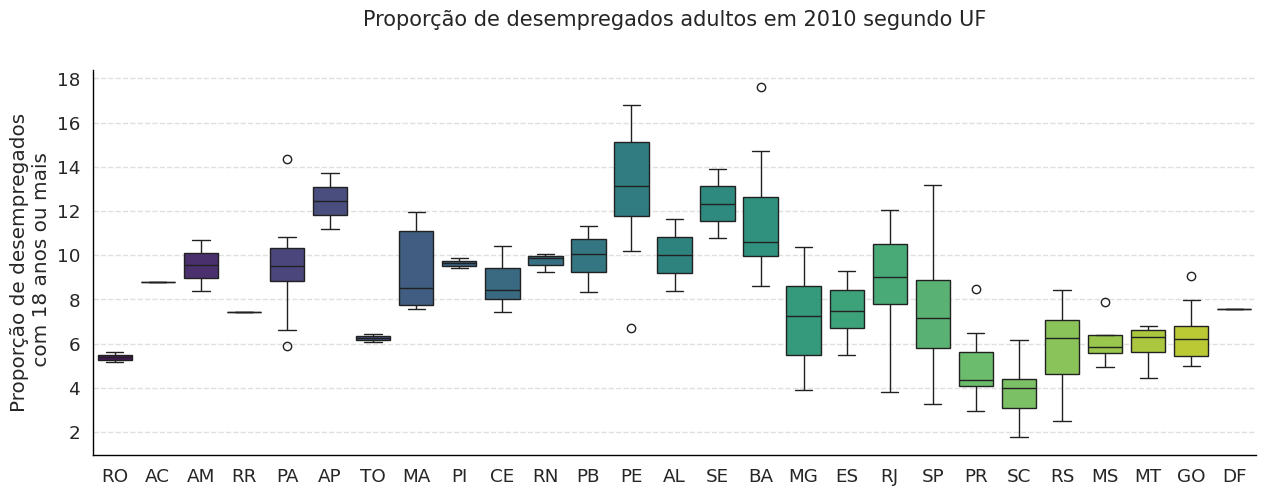

In [36]:
ed_bd_filtr.plot_box_uf(
    titulo='Proporção de desempregados adultos em 2010 segundo UF\n',
    y_label='Proporção de desempregados\n com 18 anos ou mais',
    x='uf',
    y='taxa_desocup_18_mais',
)